# Credit Scoring and Segmentation

<img src='https://fiverr-res.cloudinary.com/images/q_auto,f_auto/gigs/151724578/original/3ce7a91679544c3ab74c20e8ea3a1e2d52b3ecfe/make-logical-credit-scoring-model-for-you.jpg'>

🇹🇷 Proje Amacı:
Bu çalışmanın amacı, müşterilerin kredi verilerini kullanarak benzer risk profillerine sahip bireyleri kümeleme (clustering) yöntemi ile gruplandırmaktır. Elde edilen segmentler sayesinde müşteriler farklı kredi risk seviyelerine göre sınıflandırılarak, finansal kuruluşların daha doğru kredi kararları alması, risk yönetimini iyileştirmesi ve müşteri bazlı stratejiler geliştirmesi hedeflenmektedir.

🇬🇧 Project Objective:
The aim of this study is to group customers with similar credit risk profiles using clustering techniques based on their credit data. Through the resulting segments, customers are categorized into different risk levels, enabling financial institutions to make more accurate credit decisions, improve risk management, and develop customer-specific strategies.

In [72]:
import pandas as pd
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from yellowbrick.cluster import KElbowVisualizer

from sklearn.preprocessing import StandardScaler

In [3]:
df=pd.read_csv('credit_scoring.csv')

In [15]:
#EDA

In [4]:
df.head()

,Age,Gender,Marital Status,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Type of Loan
0,60,Male,Married,Master,Employed,0.22,2685.0,2,4675000,2.65,48,Personal Loan
1,25,Male,Married,High School,Unemployed,0.20,2371.0,9,3619000,5.19,60,Auto Loan
2,30,Female,Single,Master,Employed,0.22,2771.0,6,957000,2.76,12,Auto Loan
3,58,Female,Married,PhD,Unemployed,0.12,1371.0,2,4731000,6.57,60,Auto Loan
4,32,Male,Married,Bachelor,Self-Employed,0.99,828.0,2,3289000,6.28,36,Personal Loan


In [42]:
df.tail()

,Age,Gender,Marital Status,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Type of Loan
995,59,1,Divorced,0,2,0.74,1285.0,8,3530000,12.99,48,Auto Loan
996,64,1,Divorced,1,0,0.77,1857.0,2,1377000,18.02,60,Home Loan
997,63,0,Single,2,1,0.18,2628.0,10,2443000,18.95,12,Personal Loan
998,51,0,Married,3,1,0.32,1142.0,3,1301000,1.80,24,Auto Loan
999,37,0,Married,2,1,0.17,1028.0,5,4182000,9.34,24,Auto Loan


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   Gender                     1000 non-null   object 
 2   Marital Status             1000 non-null   object 
 3   Education Level            1000 non-null   object 
 4   Employment Status          1000 non-null   object 
 5   Credit Utilization Ratio   1000 non-null   float64
 6   Payment History            1000 non-null   float64
 7   Number of Credit Accounts  1000 non-null   int64  
 8   Loan Amount                1000 non-null   int64  
 9   Interest Rate              1000 non-null   float64
 10  Loan Term                  1000 non-null   int64  
 11  Type of Loan               1000 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


In [6]:
df.isnull().sum()

Age                          0
Gender                       0
Marital Status               0
Education Level              0
Employment Status            0
Credit Utilization Ratio     0
Payment History              0
Number of Credit Accounts    0
Loan Amount                  0
Interest Rate                0
Loan Term                    0
Type of Loan                 0
dtype: int64

In [7]:
df.describe()

,Age,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,42.702000,0.509950,1452.814000,5.580000,2.471401e+06,10.686600,37.128000
std,13.266771,0.291057,827.934146,2.933634,1.387047e+06,5.479058,17.436274
min,20.000000,0.000000,0.000000,1.000000,1.080000e+05,1.010000,12.000000
25%,31.000000,0.250000,763.750000,3.000000,1.298000e+06,6.022500,24.000000
50%,42.000000,0.530000,1428.000000,6.000000,2.437500e+06,10.705000,36.000000
75%,54.000000,0.750000,2142.000000,8.000000,3.653250e+06,15.440000,48.000000
max,65.000000,1.000000,2857.000000,10.000000,4.996000e+06,19.990000,60.000000


In [14]:
df.Gender.value_counts()

Gender
Male      501
Female    499
Name: count, dtype: int64

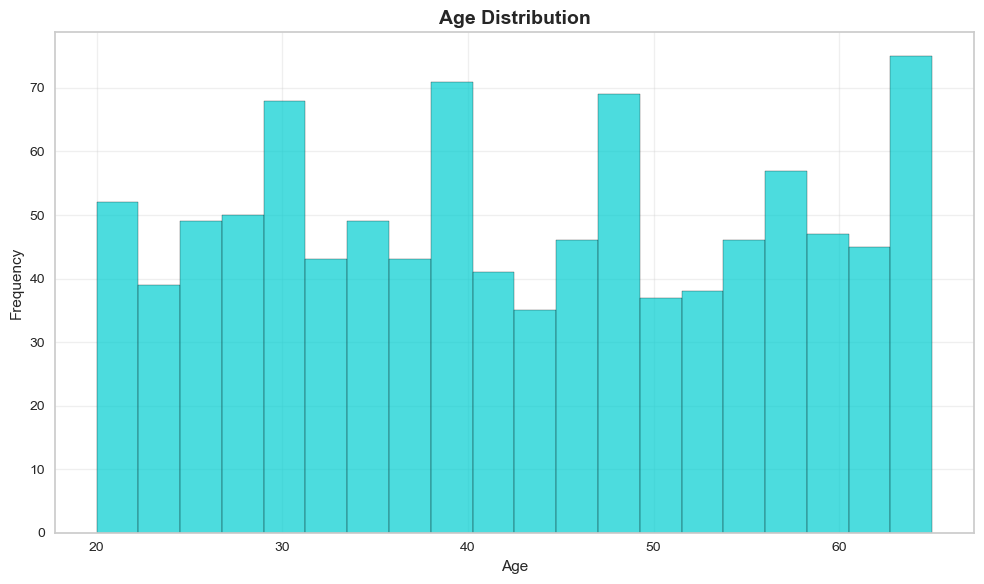

In [11]:
# Age Distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=20, color='#00CED1', edgecolor='black', alpha=0.7)
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

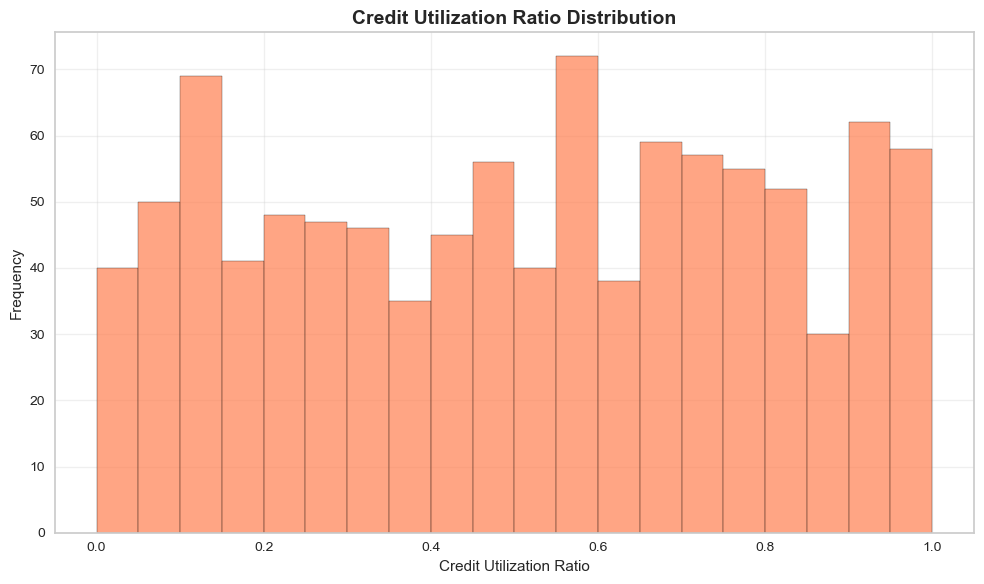

In [13]:
# Credit Utilization Ratio Distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Credit Utilization Ratio'], bins=20, color='coral', edgecolor='black', alpha=0.7)
plt.title('Credit Utilization Ratio Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Credit Utilization Ratio')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

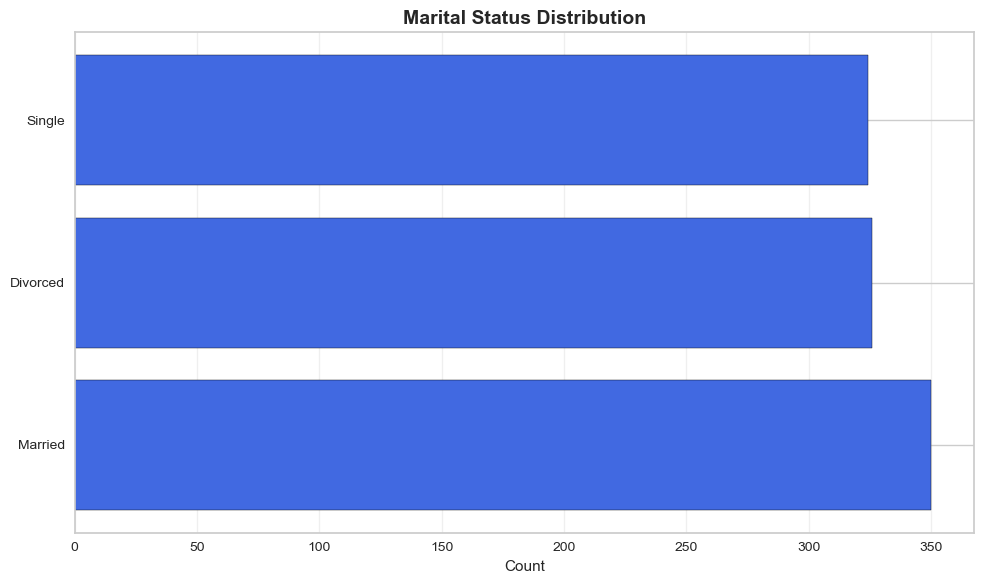

In [17]:
# Marital Status
plt.figure(figsize=(10, 6))
marital_counts = df['Marital Status'].value_counts()
plt.barh(marital_counts.index, marital_counts.values, color='#4169E1', edgecolor='black')
plt.title('Marital Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

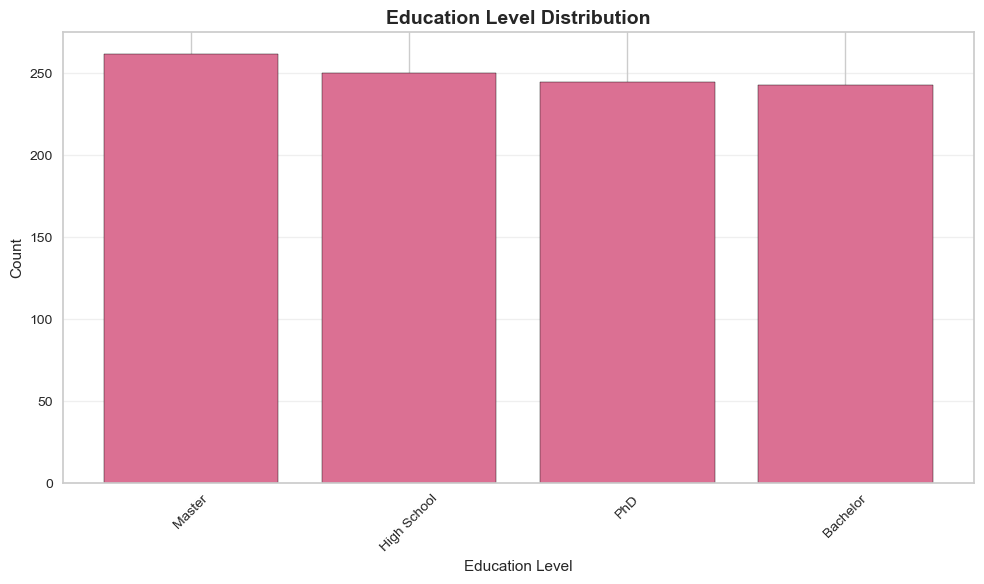

In [19]:
# Education Level Distribution
plt.figure(figsize=(10, 6))
education_counts = df['Education Level'].value_counts()
plt.bar(education_counts.index, education_counts.values, color='#DB7093', edgecolor='black')
plt.title('Education Level Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

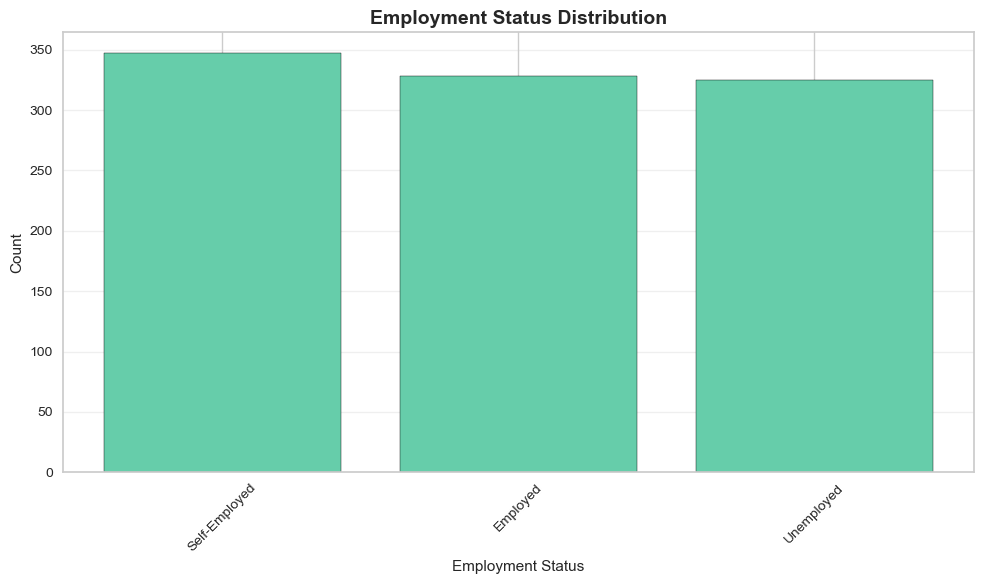

In [23]:
# Employment Status Distribution
plt.figure(figsize=(10, 6))
employment_counts = df['Employment Status'].value_counts()
plt.bar(employment_counts.index, employment_counts.values, color='#66CDAA', edgecolor='black')
plt.title('Employment Status Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Employment Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        1000 non-null   int64  
 1   Gender                     1000 non-null   object 
 2   Marital Status             1000 non-null   object 
 3   Education Level            1000 non-null   object 
 4   Employment Status          1000 non-null   object 
 5   Credit Utilization Ratio   1000 non-null   float64
 6   Payment History            1000 non-null   float64
 7   Number of Credit Accounts  1000 non-null   int64  
 8   Loan Amount                1000 non-null   int64  
 9   Interest Rate              1000 non-null   float64
 10  Loan Term                  1000 non-null   int64  
 11  Type of Loan               1000 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


In [25]:
df['Credit Utilization Ratio'].describe()

count    1000.000000
mean        0.509950
std         0.291057
min         0.000000
25%         0.250000
50%         0.530000
75%         0.750000
max         1.000000
Name: Credit Utilization Ratio, dtype: float64

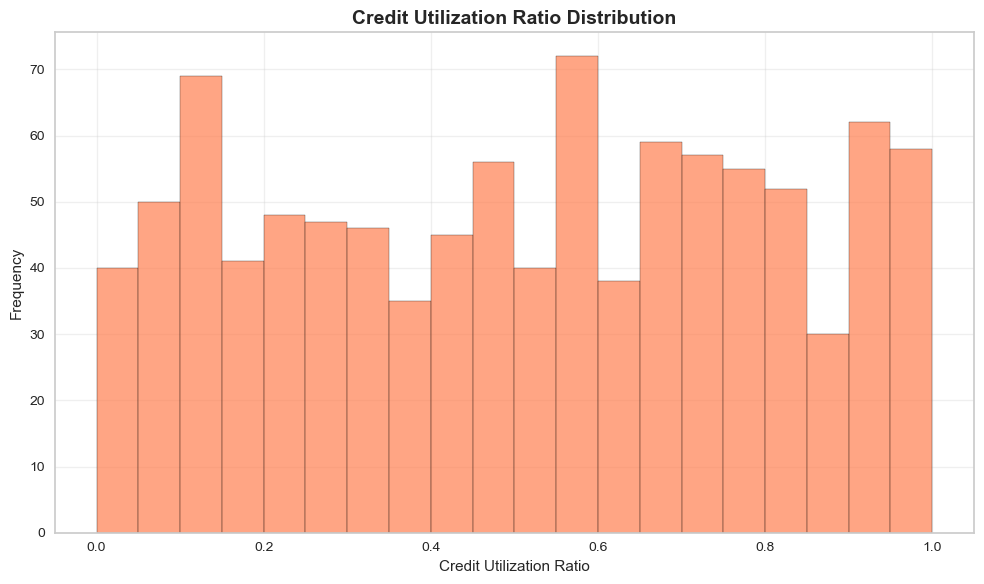

In [24]:
# Credit Utilization Ratio Distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Credit Utilization Ratio'], bins=20, color='coral', edgecolor='black', alpha=0.7)
plt.title('Credit Utilization Ratio Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Credit Utilization Ratio')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

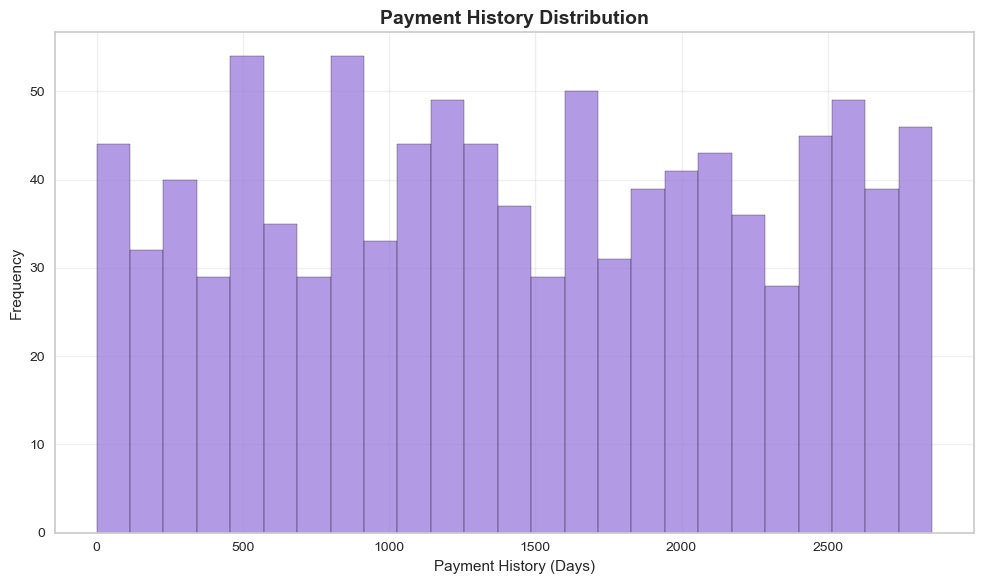

In [28]:
# Payment History Distribution
plt.figure(figsize=(10, 6))
plt.hist(df['Payment History'], bins=25, color='#9370DB', edgecolor='black', alpha=0.7)
plt.title('Payment History Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Payment History (Days)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

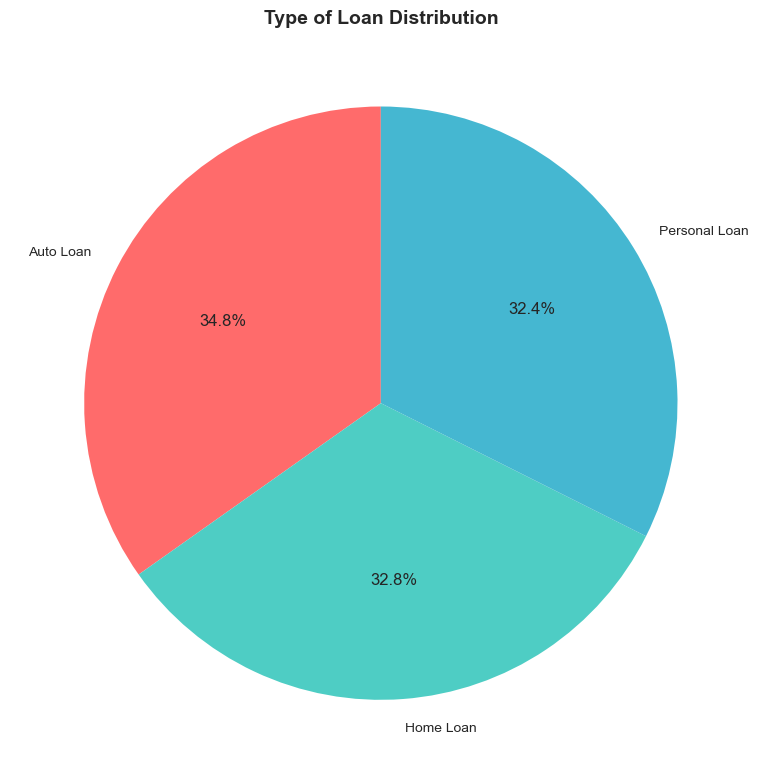

In [30]:
# Type of Loan Distribution 
plt.figure(figsize=(10, 8))
loan_type_counts = df['Type of Loan'].value_counts()
colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
plt.pie(loan_type_counts, labels=loan_type_counts.index, autopct='%1.1f%%', 
        colors=colors_pie, startangle=90)
plt.title('Type of Loan Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
#Feature Engineering

In [33]:
df.Gender.value_counts()

Gender
Male      501
Female    499
Name: count, dtype: int64

In [34]:
# Female -> 0, Male -> 1
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

In [35]:
df['Education Level'].value_counts()

Education Level
Master         262
High School    250
PhD            245
Bachelor       243
Name: count, dtype: int64

In [36]:
edu = {'High School': 0, 'Bachelor': 1, 'Master': 2, 'PhD': 3}
df['Education Level'] = df['Education Level'].map(edu)

In [38]:
df['Employment Status'].value_counts()

Employment Status
Self-Employed    347
Employed         328
Unemployed       325
Name: count, dtype: int64

In [39]:
emp = {'Unemployed': 0, 'Self-Employed': 1, 'Employed': 2}
df['Employment Status'] = df['Employment Status'].map(emp)

In [40]:
df['Type of Loan'].value_counts()

Type of Loan
Auto Loan        348
Home Loan        328
Personal Loan    324
Name: count, dtype: int64

In [43]:
df.head()

,Age,Gender,Marital Status,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Type of Loan
0,60,1,Married,2,2,0.22,2685.0,2,4675000,2.65,48,Personal Loan
1,25,1,Married,0,0,0.20,2371.0,9,3619000,5.19,60,Auto Loan
2,30,0,Single,2,2,0.22,2771.0,6,957000,2.76,12,Auto Loan
3,58,0,Married,3,0,0.12,1371.0,2,4731000,6.57,60,Auto Loan
4,32,1,Married,1,1,0.99,828.0,2,3289000,6.28,36,Personal Loan


In [44]:
# Monthly Payment Amount
df['Monthly_Payment'] = df['Loan Amount'] / df['Loan Term']

In [45]:
# Interest Rate Risk Level
df['Interest_Risk_Level'] = pd.cut(df['Interest Rate'], 
                                    bins=[0, 5, 10, 15, 20], 
                                    labels=['Low', 'Medium', 'High', 'Very High'])
interest = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
df['Interest_Risk_Level'] = df['Interest_Risk_Level'].map(interest)

In [47]:
# Credit Risk Score 
df['Credit_Risk_Score'] = (df['Credit Utilization Ratio'] * 100) * (1 - (df['Payment History'] / 3000)) ## Düşük payment history ve yüksek credit utilization = yüksek risk
df['Credit_Risk_Score'] = np.clip(df['Credit_Risk_Score'], 0, 100)  #0-100 aralığına sabitlemek

# Financial Health  Payment history'si iyi ve düşük credit utilization = sağlıklı 
df['Financial_Health'] = (df['Payment History'] / df['Payment History'].max()) - \
                         (df['Credit Utilization Ratio'] * 0.5)
df['Financial_Health'] = np.clip(df['Financial_Health'], 0, 1)

In [48]:
df.head()

,Age,Gender,Marital Status,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Type of Loan,Monthly_Payment,Interest_Risk_Level,Credit_Risk_Score,Financial_Health
0,60,1,Married,2,2,0.22,2685.0,2,4675000,2.65,48,Personal Loan,97395.833333,1,2.310000,0.829797
1,25,1,Married,0,0,0.20,2371.0,9,3619000,5.19,60,Auto Loan,60316.666667,2,4.193333,0.729891
2,30,0,Single,2,2,0.22,2771.0,6,957000,2.76,12,Auto Loan,79750.000000,1,1.679333,0.859898
3,58,0,Married,3,0,0.12,1371.0,2,4731000,6.57,60,Auto Loan,78850.000000,2,6.516000,0.419874
4,32,1,Married,1,1,0.99,828.0,2,3289000,6.28,36,Personal Loan,91361.111111,2,71.676000,0.000000


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Age                        1000 non-null   int64   
 1   Gender                     1000 non-null   int64   
 2   Marital Status             1000 non-null   object  
 3   Education Level            1000 non-null   int64   
 4   Employment Status          1000 non-null   int64   
 5   Credit Utilization Ratio   1000 non-null   float64 
 6   Payment History            1000 non-null   float64 
 7   Number of Credit Accounts  1000 non-null   int64   
 8   Loan Amount                1000 non-null   int64   
 9   Interest Rate              1000 non-null   float64 
 10  Loan Term                  1000 non-null   int64   
 11  Type of Loan               1000 non-null   object  
 12  Monthly_Payment            1000 non-null   float64 
 13  Interest_Risk_Level        1000 no

In [53]:
x=pd.get_dummies(df, drop_first=True)

In [54]:
x.head()

,Age,Gender,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,Monthly_Payment,Credit_Risk_Score,Financial_Health,Marital Status_Married,Marital Status_Single,Type of Loan_Home Loan,Type of Loan_Personal Loan,Interest_Risk_Level_2,Interest_Risk_Level_3,Interest_Risk_Level_4
0,60,1,2,2,0.22,2685.0,2,4675000,2.65,48,97395.833333,2.310000,0.829797,True,False,False,True,False,False,False
1,25,1,0,0,0.20,2371.0,9,3619000,5.19,60,60316.666667,4.193333,0.729891,True,False,False,False,True,False,False
2,30,0,2,2,0.22,2771.0,6,957000,2.76,12,79750.000000,1.679333,0.859898,False,True,False,False,False,False,False
3,58,0,3,0,0.12,1371.0,2,4731000,6.57,60,78850.000000,6.516000,0.419874,True,False,False,False,True,False,False
4,32,1,1,1,0.99,828.0,2,3289000,6.28,36,91361.111111,71.676000,0.000000,True,False,False,True,True,False,False


In [55]:
model=KMeans(4)      #Burada 4 gruba ayırıyoruz

In [56]:
model=model.fit(x)

In [57]:
tahmin=model.predict(x)

In [58]:
x['Cluster']=tahmin

In [59]:
x.head()

,Age,Gender,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,...,Credit_Risk_Score,Financial_Health,Marital Status_Married,Marital Status_Single,Type of Loan_Home Loan,Type of Loan_Personal Loan,Interest_Risk_Level_2,Interest_Risk_Level_3,Interest_Risk_Level_4,Cluster
0,60,1,2,2,0.22,2685.0,2,4675000,2.65,48,...,2.310000,0.829797,True,False,False,True,False,False,False,0
1,25,1,0,0,0.20,2371.0,9,3619000,5.19,60,...,4.193333,0.729891,True,False,False,False,True,False,False,3
2,30,0,2,2,0.22,2771.0,6,957000,2.76,12,...,1.679333,0.859898,False,True,False,False,False,False,False,2
3,58,0,3,0,0.12,1371.0,2,4731000,6.57,60,...,6.516000,0.419874,True,False,False,False,True,False,False,0
4,32,1,1,1,0.99,828.0,2,3289000,6.28,36,...,71.676000,0.000000,True,False,False,True,True,False,False,3


<Axes: xlabel='Cluster', ylabel='count'>

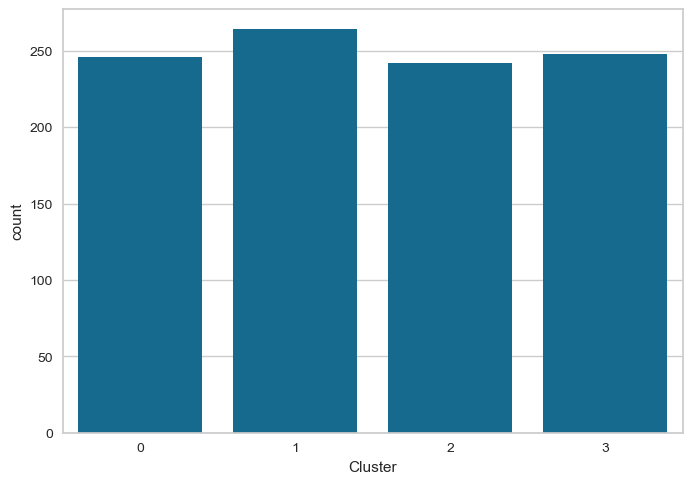

In [60]:
sns.countplot(x=x['Cluster'])

In [61]:
x.Cluster.value_counts()

Cluster
1    264
3    248
0    246
2    242
Name: count, dtype: int64

In [83]:
# Credit Score 
x['Credit_Score'] = (
    (x['Payment History'] / df['Payment History'].max()) * 0.35 +          # 35%
    (1 - x['Credit Utilization Ratio']) * 0.30 +                          # 30%
    (x['Number of Credit Accounts'] / 10) * 0.15 +                        # 15%
    (x['Financial_Health']) * 0.15 +                                      # 15%
    (1 - x['Credit_Risk_Score'] / 100) * 0.05                             # 5%
) * 850

# Categories
x['Credit_Category'] = pd.cut(x['Credit_Score'], 
                               bins=[0, 580, 670, 740, 800, 850],
                               labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])

In [84]:
x.head()

,Age,Gender,Education Level,Employment Status,Credit Utilization Ratio,Payment History,Number of Credit Accounts,Loan Amount,Interest Rate,Loan Term,...,Marital Status_Married,Marital Status_Single,Type of Loan_Home Loan,Type of Loan_Personal Loan,Interest_Risk_Level_2,Interest_Risk_Level_3,Interest_Risk_Level_4,Cluster,Credit_Score,Credit_Category
0,60,1,2,2,0.22,2685.0,2,4675000,2.65,48,...,True,False,False,True,False,False,False,1,651.306971,Fair
1,25,1,0,0,0.20,2371.0,9,3619000,5.19,60,...,True,False,False,False,True,False,False,1,699.421719,Good
2,30,0,2,2,0.22,2771.0,6,957000,2.76,12,...,False,True,False,False,False,False,False,1,715.368144,Good
3,58,0,3,0,0.12,1371.0,2,4731000,6.57,60,...,True,False,False,False,True,False,False,1,485.927147,Poor
4,32,1,1,1,0.99,828.0,2,3289000,6.28,36,...,True,False,False,True,True,False,False,3,126.307511,Poor


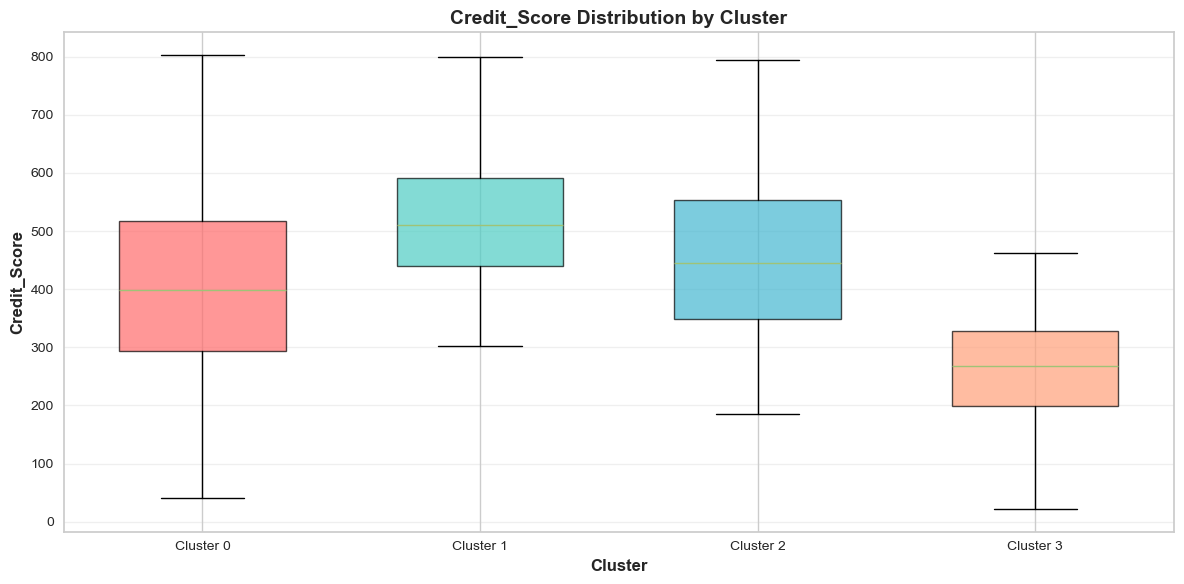

In [90]:
#Credit_Score by Cluster
plt.figure(figsize=(12, 6))
cluster_data = [x[x['Cluster'] == i]['Credit_Score'].values for i in sorted(x['Cluster'].unique())]
bp = plt.boxplot(cluster_data, labels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'],
                 patch_artist=True, widths=0.6)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Credit_Score Distribution by Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12, fontweight='bold')
plt.ylabel('Credit_Score', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

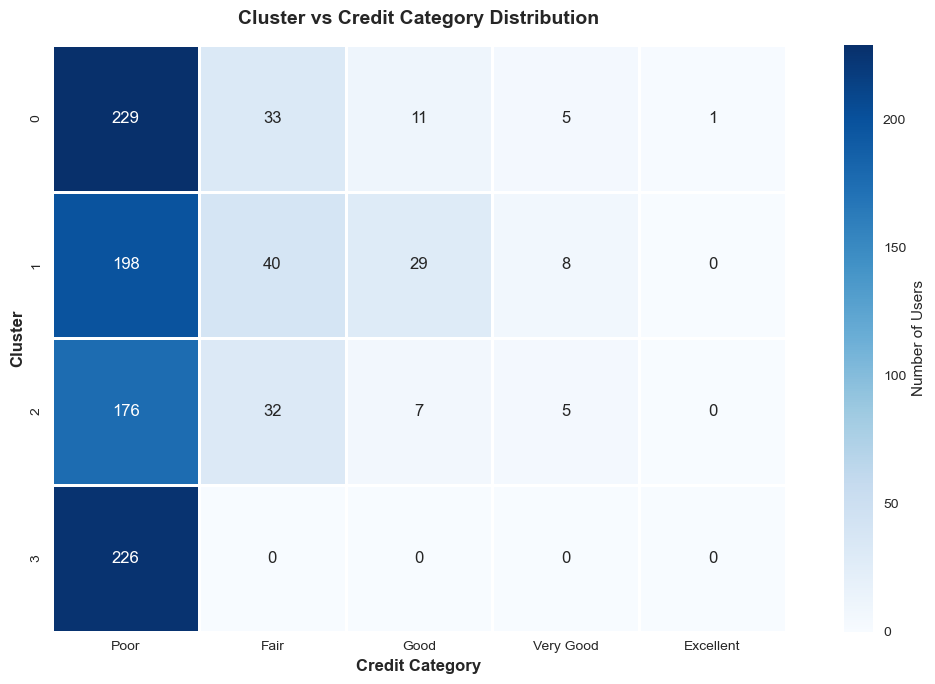

In [97]:
# Heatmap oluştur
plt.figure(figsize=(12, 7))

# Cross-tabulation
cluster_category = pd.crosstab(x['Cluster'], x['Credit_Category'])
cluster_category = cluster_category[['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']]

# Confusion Matrix Style Heatmap
sns.heatmap(cluster_category, annot=True, fmt='d', cmap='Blues', 
            cbar_kws={'label': 'Number of Users'}, 
            linewidths=2, linecolor='white',
            square=True, vmin=0, vmax=cluster_category.values.max())

plt.title('Cluster vs Credit Category Distribution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Credit Category', fontsize=12, fontweight='bold')
plt.ylabel('Cluster', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [98]:
x.Credit_Category.value_counts()

Credit_Category
Poor         829
Fair         105
Good          47
Very Good     18
Excellent      1
Name: count, dtype: int64

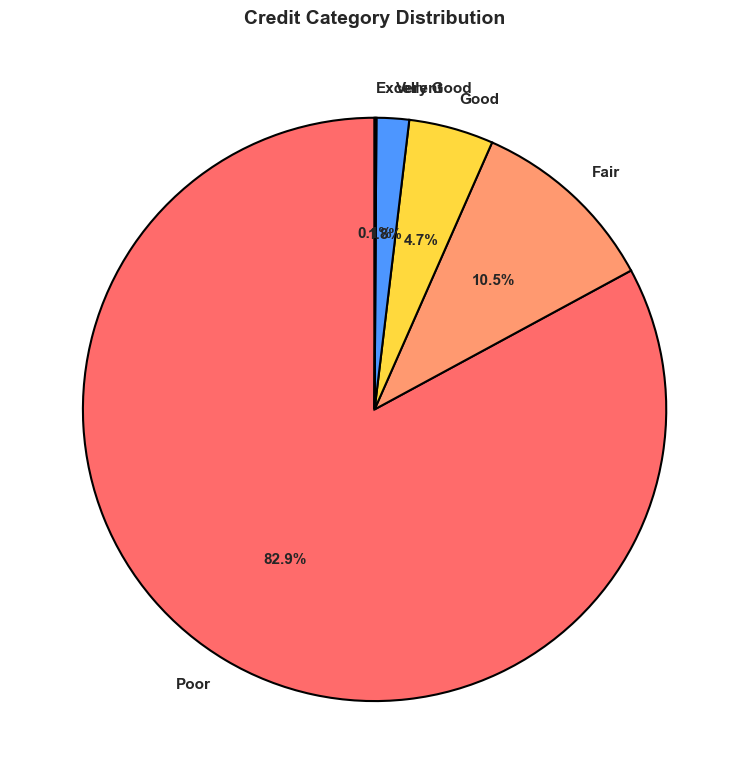

In [99]:
plt.figure(figsize=(10, 8))

categories = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
values = [829, 105, 47, 18, 1]
colors = ['#FF6B6B', '#FF9970', '#FFD93D', '#4D96FF', '#6BCB77']

plt.pie(values, labels=categories, autopct='%1.1f%%', 
        colors=colors, startangle=90, 
        textprops={'fontsize': 11, 'fontweight': 'bold'},
        wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})

plt.title('Credit Category Distribution', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

In [62]:
silhouette_score(x,tahmin)

0.5598774815009094

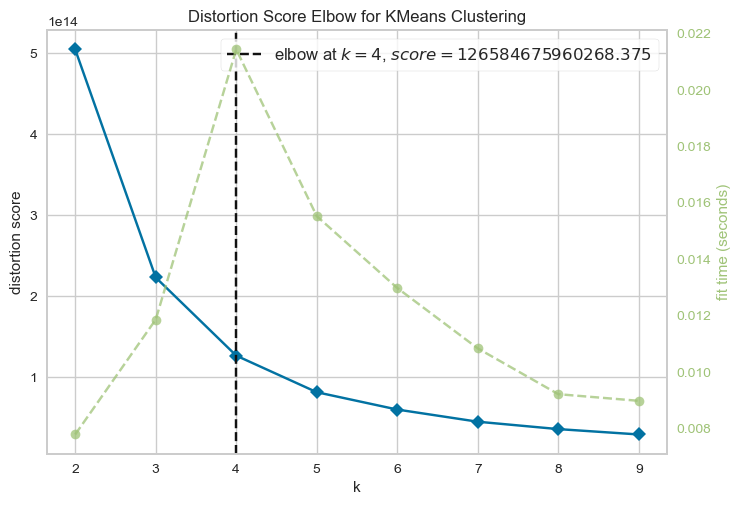

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [63]:
vis=KElbowVisualizer(KMeans(), k=(2,10))           #zaten datayı gruplara ayıracağımız için 1e bölmek demek datanın kendisine bölmek oluyor
vis.fit(x)
vis.show()

In [64]:
#wcss= within cluster sum of squares uzaklıkları hesaplayarak türev alarak en optimum uzaklığı buluyor yer seçimi için inceleyebiliriz
wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(x)
    tahmin=model.predict(x)
    ss1=silhouette_score(x,tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.6127343552420448
0.5806999442909405
0.5598774815009094
0.5503232779634325
0.5364124560601303
0.5066855889667825
0.4966957795936421
0.5166061028795144


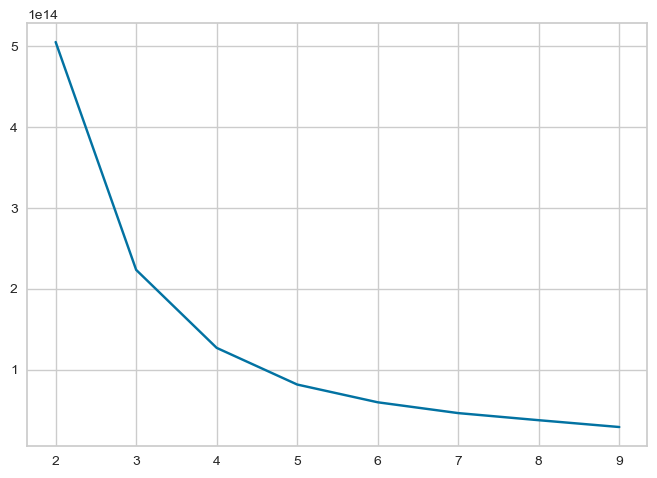

In [65]:
plt.plot(range(2,10), wcss)   #dirsek nerede kırılırsa optimum grup o kadardır.

In [66]:
## Hierarchical Clustering 

In [67]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [68]:
data=linkage(x,method='ward',metric='euclidean')

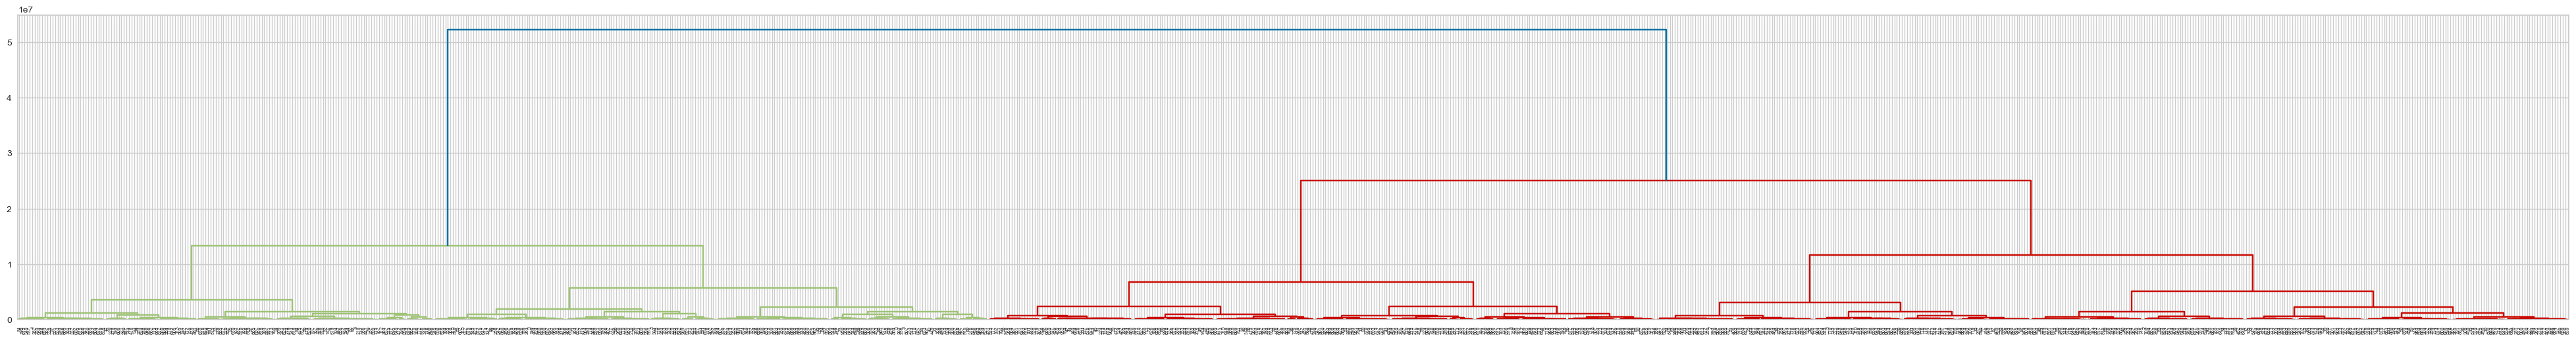

In [69]:
plt.figure(figsize=(50,6))
dendrogram(data);

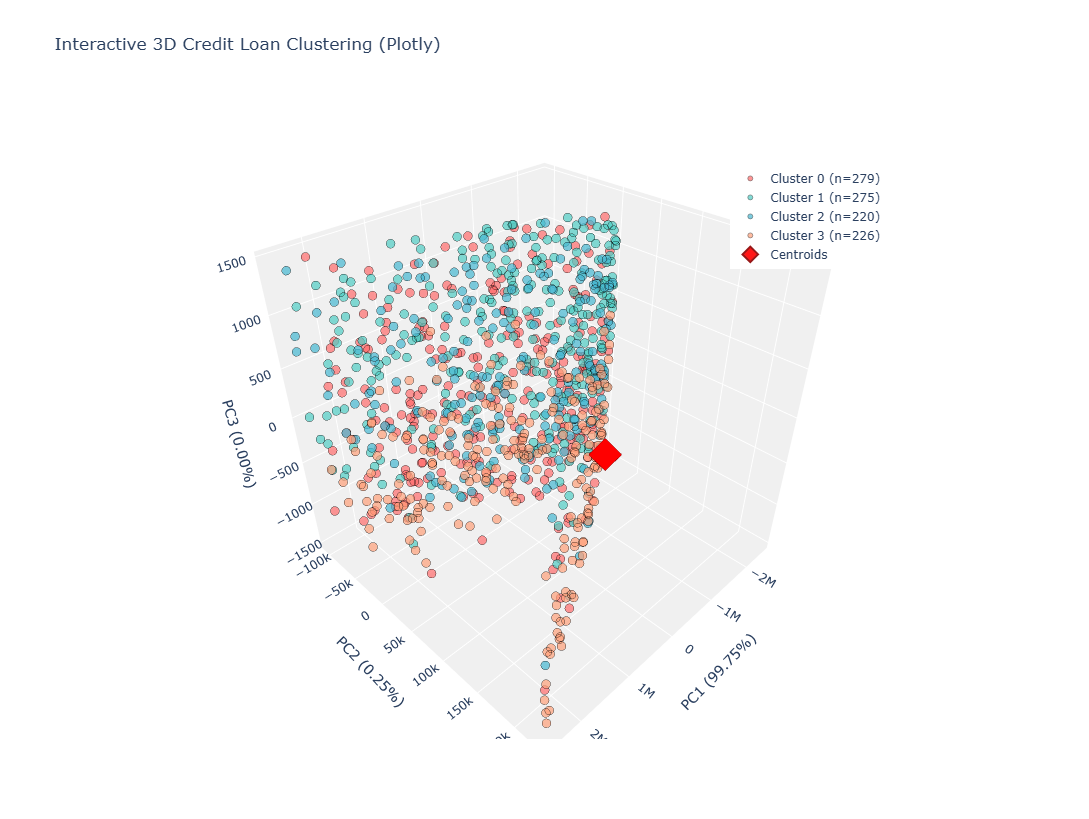

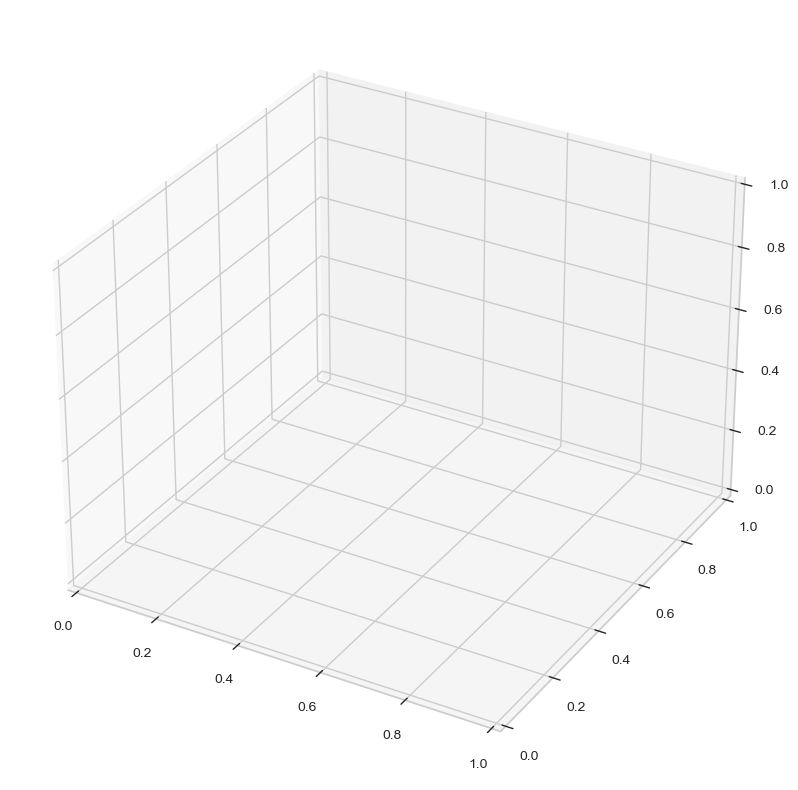

In [78]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(x)

# ============================================================
#  MATPLOTLIB - 3D PLOTTİNG 
# ============================================================

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
cluster_labels = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'}
cluster_names = {
    0: 'Young & High Risk',
    1: 'Mature & Stable',
    2: 'Mid-Career & Active',
    3: 'Established Borrowers'
}

fig_plotly = go.Figure()

# Her cluster için scatter plot
for cluster_id in sorted(np.unique(clusters)):
    cluster_mask = clusters == cluster_id
    cluster_size = np.sum(cluster_mask)
    
    fig_plotly.add_trace(go.Scatter3d(
        x=X_pca[cluster_mask, 0],
        y=X_pca[cluster_mask, 1],
        z=X_pca[cluster_mask, 2],
        mode='markers',
        name=f'{cluster_labels[cluster_id]} (n={cluster_size})',
        marker=dict(
            size=5,
            color=colors[cluster_id],
            opacity=0.7,
            line=dict(width=0.5, color='black')
        ),
        text=[f'Cluster {cluster_id}' for _ in range(cluster_size)],
        hovertemplate='<b>%{text}</b><br>PC1: %{x:.3f}<br>PC2: %{y:.3f}<br>PC3: %{z:.3f}<extra></extra>'
    ))

# Centroids
fig_plotly.add_trace(go.Scatter3d(
    x=centroids_pca[:, 0],
    y=centroids_pca[:, 1],
    z=centroids_pca[:, 2],
    mode='markers',
    name='Centroids',
    marker=dict(
        size=12,
        color='red',
        symbol='diamond',
        line=dict(width=2, color='darkred'),
        opacity=0.9
    ),
    hovertemplate='<b>Centroid</b><br>PC1: %{x:.3f}<br>PC2: %{y:.3f}<br>PC3: %{z:.3f}<extra></extra>'
))

# Layout
fig_plotly.update_layout(
    title='Interactive 3D Credit Loan Clustering (Plotly)',
    scene=dict(
        xaxis=dict(
            title=f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
            backgroundcolor="rgb(240, 240, 240)",
            gridcolor="white"
        ),
        yaxis=dict(
            title=f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
            backgroundcolor="rgb(240, 240, 240)",
            gridcolor="white"
        ),
        zaxis=dict(
            title=f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)',
            backgroundcolor="rgb(240, 240, 240)",
            gridcolor="white"
        ),
    ),
    width=1200,
    height=800,
    hovermode='closest',
    font=dict(size=12),
    showlegend=True,
    legend=dict(x=0.7, y=0.9)
)

fig_plotly.show()


🇹🇷 Sonuç:
Kümeleme analizi sonucunda veri seti 4 farklı kredi risk segmentine ayrılmıştır. Bu kümeler, müşterilerin ödeme geçmişi, kredi kullanımı ve diğer finansal davranışlarına göre anlamlı gruplar oluşturarak, her bir segment için ayrı risk değerlendirmeleri ve kredi stratejileri geliştirilmesine olanak sağlamaktadır.

🇬🇧 Result:
As a result of the clustering analysis, the dataset was divided into 4 distinct credit risk segments. These clusters form meaningful groups based on customers’ payment history, credit utilization, and other financial behaviors, allowing for separate risk assessments and credit strategies to be developed for each segment.